# 04 · Red generativa adversaria condicional (cGAN)

**Taller B5-T1 · Generación de datos financieros sintéticos**

Primero de los tres modelos generativos neuronales del proyecto. Una red
adversaria enfrenta dos redes con objetivos opuestos: un generador que produce
ventanas artificiales a partir de ruido y un discriminador que trata de
distinguirlas de las reales. El generador nunca ve los datos originales, y toda
la información que recibe sobre ellos le llega a través del gradiente del
discriminador.

La variante condicional añade la etiqueta como entrada a ambas redes. Esto
permite pedir al generador muestras de una clase concreta, que es exactamente lo
que interesa aquí: el análisis exploratorio mostro que la carencia del problema
no es el número de observaciones sino la variedad de episodios de estrés, de modo
que un generador que solo produjese ventanas tranquilas no resolvería nada.

**Salidas:** `models/sinteticos_cgan.npz` y `results/tablas/resultados_cgan.csv`

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\raulr\Documents\MIAX\Practicas\B5-T1


## 1. Datos de partida

Se carga el dataset y se extrae el presupuesto de datos reales fijado en el
notebook 02. Las redes operan sobre la ventana aplanada, con lo que cada
observación pasa a ser un vector de 1380 componentes que recoge las sesenta
sesiones de los veintitrés activos.

El generador se entrena únicamente con este subconjunto. Utilizar el histórico
completo le daría acceso a información vedada al clasificador e invalidaria la
comparación.

In [2]:
d = datos.cargar_dataset()

X_real, y_real = datos.submuestra_real(
    d["X_train"], d["y_train"], config.N_REALES, config.SEMILLA)

X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

n_pasos, n_activos = X_real.shape[1], X_real.shape[2]
DIMENSION = n_pasos * n_activos
X_plano = X_real.reshape(len(X_real), DIMENSION)

print(f"Presupuesto real: {X_real.shape}")
print(f"Positivas: {int(y_real.sum())} ({y_real.mean():.1%})")
print(f"Dimensión de la ventana aplanada: {DIMENSION}")

Presupuesto real: (3000, 60, 23)
Positivas: 301 (10.0%)
Dimensión de la ventana aplanada: 1380


## 2. Fundamento del modelo

El entrenamiento adversario plantea un problema de dos jugadores. El
discriminador aprende a asignar probabilidad alta a las ventanas reales y baja a
las generadas; el generador aprende a producir ventanas que el discriminador
clasifique como reales. Ninguno de los dos minimiza una función fija, porque el
objetivo de cada uno depende del estado del otro.

Esa es la característica que distingue a estos modelos de un ajuste
convencional, y tiene una consecuencia práctica sobre la lectura de las curvas
de pérdida: **no debe esperarse un descenso monótono**. Una pérdida del generador
que cae a cero no indica éxito sino que el discriminador ha dejado de suponer un
adversario útil. Lo que se busca es un equilibrio en el que ninguna de las dos
redes domine de forma sostenida, y el indicador natural de ese equilibrio es la
tasa de acierto del discriminador: si se estabiliza cerca de la mitad, ya no
distingue las muestras generadas de las reales.

El condicionamiento se implementa concatenando la etiqueta al vector de entrada
de ambas redes. El discriminador evalúa así la pareja formada por la ventana y su
clase, lo que obliga al generador no solo a producir ventanas verosímiles sino a
que se correspondan con la clase solicitada.

La elección de una arquitectura densa sobre la ventana aplanada, en lugar de
convolucional, sigue el planteamiento habitual para este tipo de datos
tabulares de dimensión moderada y mantiene el coste de entrenamiento dentro de
lo asumible en un procesador convencional.

## 3. Arquitectura

El generador transforma un vector de ruido de cien componentes, junto con la
etiqueta, en una ventana completa. Se emplean tres capas densas de anchura
creciente con activación lineal rectificada con fuga, que evita que las unidades
queden inactivas, y normalización por lotes, que estabiliza el entrenamiento
adversario. La capa de salida usa tangente hiperbólica porque los datos están
escalados al intervalo que esa función recorre.

In [3]:
from keras import Model, layers
from keras.optimizers import Adam

DIM_RUIDO = 100

def construir_generador():
    ruido = layers.Input(shape=(DIM_RUIDO,), name="ruido")
    etiqueta = layers.Input(shape=(1,), name="etiqueta")

    h = layers.Concatenate()([ruido, etiqueta])
    for unidades in (256, 512, 1024):
        h = layers.Dense(unidades)(h)
        h = layers.LeakyReLU(negative_slope=0.2)(h)
        h = layers.BatchNormalization(momentum=0.8)(h)

    ventana = layers.Dense(DIMENSION, activation="tanh", name="ventana")(h)
    return Model([ruido, etiqueta], ventana, name="generador")


keras.utils.set_random_seed(config.SEMILLA)
generador = construir_generador()
generador.summary()

Model: "generador"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ruido (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ etiqueta            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 101)       │          0 │ ruido[0][0],      │
│ (Concatenate)       │                   │            │ etiqueta[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     26,112 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 1024)      │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ventana (Dense)     │ (None, 1380)      │  1,414,500 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,104,676 (8.03 MB)

 Trainable params: 2,101,092 (8.02 MB)

 Non-trainable params: 3,584 (14.00 KB)

El discriminador recibe una ventana junto con su etiqueta y emite la
probabilidad de que la pareja proceda de los datos reales. Se incorpora abandono
entre capas para impedir que aprenda demasiado deprisa: un discriminador que
acierte siempre deja de proporcionar gradiente útil al generador y detiene el
aprendizaje.

In [4]:
def construir_discriminador():
    ventana = layers.Input(shape=(DIMENSION,), name="ventana")
    etiqueta = layers.Input(shape=(1,), name="etiqueta")

    h = layers.Concatenate()([ventana, etiqueta])
    for unidades in (512, 256):
        h = layers.Dense(unidades)(h)
        h = layers.LeakyReLU(negative_slope=0.2)(h)
        h = layers.Dropout(0.3)(h)

    validez = layers.Dense(1, activation="sigmoid", name="validez")(h)
    return Model([ventana, etiqueta], validez, name="discriminador")


discriminador = construir_discriminador()
discriminador.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=2e-4, beta_1=0.5),
    metrics=["accuracy"],
)
discriminador.summary()

Model: "discriminador"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ventana             │ (None, 1380)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ etiqueta            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1381)      │          0 │ ventana[0][0],    │
│ (Concatenate)       │                   │            │ etiqueta[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    707,584 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 512)       │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 256)       │          0 │ dense_4[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validez (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 839,169 (3.20 MB)

 Trainable params: 839,169 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

El modelo combinado encadena generador y discriminador. Se entrena presentando
ruido y pidiendo que el discriminador responda que la muestra es real: el
gradiente resultante empuja al generador hacia muestras más convincentes.

Durante este paso el discriminador debe permanecer congelado, ya que de lo
contrario aprendería a aceptar como reales las muestras falsas, que es lo
contrario de su cometido.

**Nota sobre el entorno.** El procedimiento habitual consiste en fijar
`discriminador.trainable = False` una sola vez antes de construir el modelo
combinado. En la versión de Keras empleada aquí ese atributo se consulta en cada
llamada y no en el momento de la compilación, de modo que el ajuste permanente
deja al discriminador sin entrenar durante todo el proceso. El síntoma es
inconfundible: su tasa de acierto se desploma a cero y la pérdida del generador
tiende a cero, situación que corresponde a un colapso completo del entrenamiento.

La solución consiste en alternar el atributo de forma explícita en cada
iteración, activándolo para el paso del discriminador y desactivándolo para el
del generador. Es lo que hace el bucle de la sección siguiente.

In [5]:
discriminador.trainable = False

ruido_entrada = layers.Input(shape=(DIM_RUIDO,))
etiqueta_entrada = layers.Input(shape=(1,))
modelo_adversario = Model(
    [ruido_entrada, etiqueta_entrada],
    discriminador([generador([ruido_entrada, etiqueta_entrada]), etiqueta_entrada]),
    name="cgan",
)
modelo_adversario.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=2e-4, beta_1=0.5),
)

print(f"Pesos entrenables del modelo combinado: "
      f"{len(modelo_adversario.trainable_weights)}")
print(f"Pesos entrenables del generador:        "
      f"{len(generador.trainable_weights)}")
print("Ambos números coinciden: el discriminador queda excluido del paso del "
      "generador.")

Pesos entrenables del modelo combinado: 14
Pesos entrenables del generador:        14
Ambos números coinciden: el discriminador queda excluido del paso del generador.


## 4. Entrenamiento

Cada iteración consta de dos pasos. En el primero se entrena el discriminador con
un lote de ventanas reales y otro de generadas. En el segundo se entrena el
generador a través del modelo combinado.

Se aplica un suavizado de etiquetas en el lado real, presentando el valor 0.9 en
lugar de 1.0. Es una práctica habitual que impide que el discriminador alcance
una confianza excesiva y que el gradiente que llega al generador se anule.

Las etiquetas de las muestras generadas se sortean con la misma proporción de
positivos que presentan los datos reales, de modo que el generador reciba
suficiente señal sobre la clase minoritaria.

In [6]:
ITERACIONES = 12000
LOTE = 64

rng = np.random.default_rng(config.SEMILLA)
perdida_disc, perdida_gen, acierto_disc = [], [], []

def sortear_etiquetas(n):
    return rng.choice(
        [0.0, 1.0], size=(n, 1),
        p=[1 - config.PROPORCION_POSITIVOS, config.PROPORCION_POSITIVOS],
    ).astype("float32")


for iteración in range(ITERACIONES):
    # --- Paso del discriminador ---
    índices = rng.integers(0, len(X_plano), LOTE)
    ventanas_reales = X_plano[índices]
    etiquetas_reales = y_real[índices].reshape(-1, 1)

    ruido = rng.normal(0, 1, (LOTE, DIM_RUIDO)).astype("float32")
    etiquetas_falsas = sortear_etiquetas(LOTE)
    ventanas_falsas = generador.predict([ruido, etiquetas_falsas], verbose=0)

    discriminador.trainable = True
    d_real = discriminador.train_on_batch(
        [ventanas_reales, etiquetas_reales],
        np.full((LOTE, 1), 0.9, dtype="float32"))
    d_falso = discriminador.train_on_batch(
        [ventanas_falsas, etiquetas_falsas],
        np.zeros((LOTE, 1), dtype="float32"))

    # --- Paso del generador ---
    discriminador.trainable = False
    ruido = rng.normal(0, 1, (LOTE, DIM_RUIDO)).astype("float32")
    etiquetas_falsas = sortear_etiquetas(LOTE)
    g_loss = modelo_adversario.train_on_batch(
        [ruido, etiquetas_falsas], np.ones((LOTE, 1), dtype="float32"))

    perdida_disc.append(0.5 * (float(d_real[0]) + float(d_falso[0])))
    acierto_disc.append(0.5 * (float(d_real[1]) + float(d_falso[1])))
    perdida_gen.append(float(g_loss))

    if iteración % 1000 == 0:
        print(f"iteración {iteración:>6d}  "
              f"pérdida D {perdida_disc[-1]:.4f}  "
              f"acierto D {acierto_disc[-1]:.3f}  "
              f"pérdida G {perdida_gen[-1]:.4f}")

print("\nEntrenamiento finalizado.")

iteración      0  pérdida D 0.7583  acierto D 0.023  pérdida G 0.5617


iteración   1000  pérdida D 0.5119  acierto D 0.430  pérdida G 2.3708


iteración   2000  pérdida D 0.7132  acierto D 0.133  pérdida G 0.6537


iteración   3000  pérdida D 0.6919  acierto D 0.500  pérdida G 0.7961


iteración   4000  pérdida D 0.3889  acierto D 0.445  pérdida G 4.1436


...

iteración   8000  pérdida D 0.4496  acierto D 0.453  pérdida G 2.4625


iteración   9000  pérdida D 0.4098  acierto D 0.430  pérdida G 3.2744


iteración  10000  pérdida D 0.4359  acierto D 0.414  pérdida G 2.8984


iteración  11000  pérdida D 0.4165  acierto D 0.453  pérdida G 3.3754



Entrenamiento finalizado.


## 5. Convergencia

Se representa la evolución de ambas pérdidas y la tasa de acierto del
discriminador. Como se indicó, el criterio de convergencia de un modelo
adversario no es el descenso de la pérdida sino la permanencia en un régimen
equilibrado.

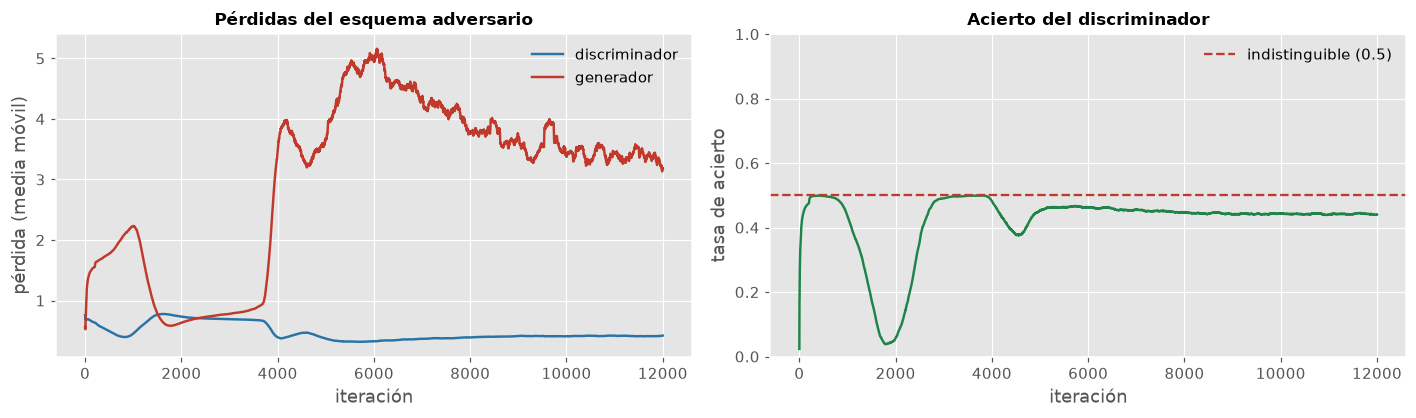

Acierto medio del discriminador en las últimas 1000 iteraciones: 0.442
Pérdida media del discriminador: 0.4149
Pérdida media del generador:     3.3495


In [7]:
def suavizar(serie, ventana=200):
    return pd.Series(serie).rolling(ventana, min_periods=1).mean().values

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))

axes[0].plot(suavizar(perdida_disc), label="discriminador", color="#2874a6",
             linewidth=1.6)
axes[0].plot(suavizar(perdida_gen), label="generador", color="#c0392b",
             linewidth=1.6)
axes[0].set_xlabel("iteración")
axes[0].set_ylabel("pérdida (media móvil)")
axes[0].set_title("Pérdidas del esquema adversario")
axes[0].legend()

axes[1].plot(suavizar(acierto_disc), color="#1e8449", linewidth=1.6)
axes[1].axhline(0.5, color="#c0392b", linestyle="--",
                label="indistinguible (0.5)")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("iteración")
axes[1].set_ylabel("tasa de acierto")
axes[1].set_title("Acierto del discriminador")
axes[1].legend()

fig.tight_layout()
graficos.guardar(fig, "04_convergencia_cgan")
plt.show()

print(f"Acierto medio del discriminador en las últimas 1000 iteraciones: "
      f"{np.mean(acierto_disc[-1000:]):.3f}")
print(f"Pérdida media del discriminador: {np.mean(perdida_disc[-1000:]):.4f}")
print(f"Pérdida media del generador:     {np.mean(perdida_gen[-1000:]):.4f}")

## 6. Generación

Se producen las muestras sintéticas muestreando ruido y sorteando etiquetas con
la proporción de positivos de los datos reales. El número generado cubre el ratio
máximo del barrido posterior, de modo que ninguna configuración tenga que repetir
muestras.

In [8]:
N_SINTETICOS = int(config.N_REALES * max(config.RATIOS_SINTETICOS))

ruido = rng.normal(0, 1, (N_SINTETICOS, DIM_RUIDO)).astype("float32")
etiquetas = sortear_etiquetas(N_SINTETICOS)

X_synth = generador.predict([ruido, etiquetas], verbose=0)
X_synth = X_synth.reshape(N_SINTETICOS, n_pasos, n_activos).astype("float32")
y_synth = etiquetas.ravel().astype("float32")

print(f"Muestras sintéticas: {X_synth.shape}")
print(f"Positivas: {int(y_synth.sum())} ({y_synth.mean():.1%})")
print(f"Rango: [{X_synth.min():.3f}, {X_synth.max():.3f}]")
print(f"Fracción saturada en los extremos: "
      f"{100 * float((np.abs(X_synth) > 0.99).mean()):.3f} %")
print(f"Desviación típica: sintética {X_synth.std():.4f}, real {X_real.std():.4f}")

Muestras sintéticas: (12000, 60, 23)
Positivas: 1186 (9.9%)
Rango: [-1.000, 1.000]
Fracción saturada en los extremos: 1.584 %
Desviación típica: sintética 0.2726, real 0.2408


## 7. Validación cualitativa

Se contrastan las muestras con las reales en los aspectos que el análisis
exploratorio identifico como determinantes.

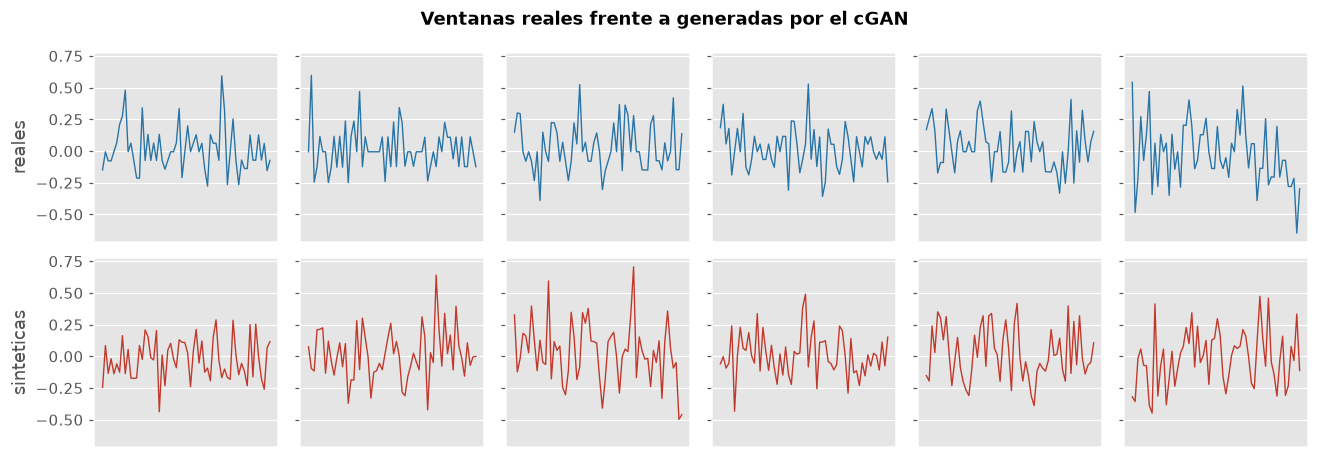

In [9]:
graficos.comparar_trayectorias(
    X_real, X_synth, "Ventanas reales frente a generadas por el cGAN",
    "04_trayectorias")
plt.show()

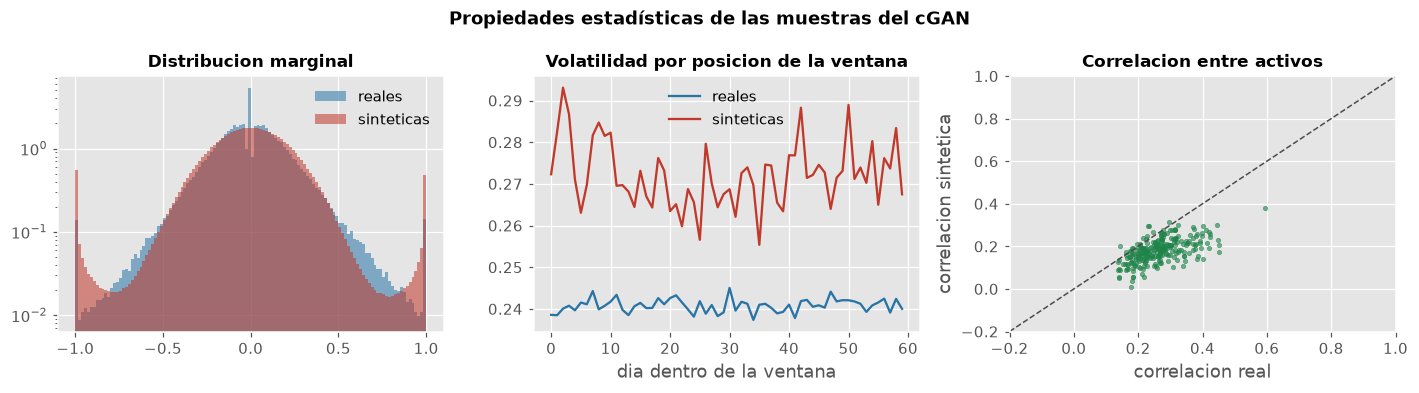

In [10]:
graficos.comparar_distribuciones(
    X_real, X_synth, "Propiedades estadísticas de las muestras del cGAN",
    "04_distribuciones")
plt.show()

In [11]:
from scipy import stats

corr_real = np.corrcoef(X_real.reshape(-1, n_activos).T)
corr_synth = np.corrcoef(X_synth.reshape(-1, n_activos).T)
triangulo = np.triu_indices(n_activos, k=1)

comparación = pd.DataFrame({
    "reales": {
        "desviación típica": float(X_real.std()),
        "curtosis": float(stats.kurtosis(X_real.ravel())),
        "asimetría": float(stats.skew(X_real.ravel())),
        "correlación media entre activos": float(corr_real[triangulo].mean()),
    },
    "sintéticas": {
        "desviación típica": float(X_synth.std()),
        "curtosis": float(stats.kurtosis(X_synth.ravel())),
        "asimetría": float(stats.skew(X_synth.ravel())),
        "correlación media entre activos": float(corr_synth[triangulo].mean()),
    },
})
display(comparación.round(4))

,reales,sintéticas
desviación típica,0.2408,0.2726
curtosis,2.1970,2.8971
asimetría,0.0818,-0.0773
correlación media entre activos,0.2657,0.1820


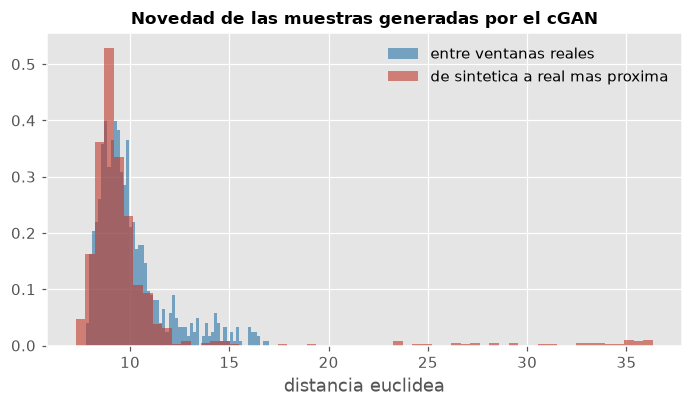

distancia_media_sintetica: 10.2788
distancia_media_real: 10.0454
ratio: 1.0232


In [12]:
fig, ax, resumen_novedad = graficos.novedad_vecino_mas_cercano(
    X_real, X_synth, "Novedad de las muestras generadas por el cGAN",
    "04_novedad")
plt.show()

for clave, valor in resumen_novedad.items():
    print(f"{clave}: {valor:.4f}")

## 8. Evaluación

Se ejecuta el protocolo común de evaluación, idéntico al aplicado al resto de
generadores.

In [13]:
resultados_cgan, historias_cgan = experimento.barrido_ratios(
    "cgan", X_real, y_real, X_synth, y_synth, X_val, y_val, X_test, y_test)

experimento.guardar_sinteticos(
    "cgan", X_synth, y_synth,
    perdidas={"discriminador": perdida_disc, "generador": perdida_gen,
              "acierto_discriminador": acierto_disc})
ruta = experimento.guardar_resultados(resultados_cgan, "cgan")
print(f"\nResultados guardados en {ruta}")

resumen_cgan = experimento.resumir(resultados_cgan)
display(resumen_cgan.round(4))

  cgan       ratio=0.00  semilla=42 PR-AUC(test)=0.3372 PR-AUC(val)=0.3276 F1=0.2755


  cgan       ratio=0.00  semilla=43 PR-AUC(test)=0.2906 PR-AUC(val)=0.3649 F1=0.2970


  cgan       ratio=0.00  semilla=44 PR-AUC(test)=0.1680 PR-AUC(val)=0.3235 F1=0.1887


  cgan       ratio=0.00  semilla=45 PR-AUC(test)=0.1158 PR-AUC(val)=0.3074 F1=0.1732


  cgan       ratio=0.00  semilla=46 PR-AUC(test)=0.3101 PR-AUC(val)=0.3281 F1=0.2566


...

  cgan       ratio=4.00  semilla=44 PR-AUC(test)=0.2518 PR-AUC(val)=0.3043 F1=0.2465


  cgan       ratio=4.00  semilla=45 PR-AUC(test)=0.3131 PR-AUC(val)=0.3488 F1=0.2959


  cgan       ratio=4.00  semilla=46 PR-AUC(test)=0.3340 PR-AUC(val)=0.3092 F1=0.2772



Resultados guardados en C:\Users\raulr\Documents\MIAX\Practicas\B5-T1\results\tablas\resultados_cgan.csv


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,cgan,0.00,0.2443,0.0967,0.3303,0.0211,0.2382,0.0544,0.2790,0.2701,0
1,cgan,0.25,0.2547,0.0675,0.3352,0.0124,0.2665,0.0311,0.3885,0.2274,750
2,cgan,0.50,0.2715,0.0342,0.3244,0.0393,0.2753,0.0369,0.4247,0.2077,1500
3,cgan,1.00,0.2806,0.0384,0.3218,0.0066,0.2984,0.0288,0.3440,0.3074,3000
4,cgan,2.00,0.2890,0.0381,0.3401,0.0222,0.3099,0.0293,0.3959,0.2725,6000
5,cgan,4.00,0.2701,0.0558,0.3190,0.0174,0.2767,0.0192,0.3432,0.2404,12000


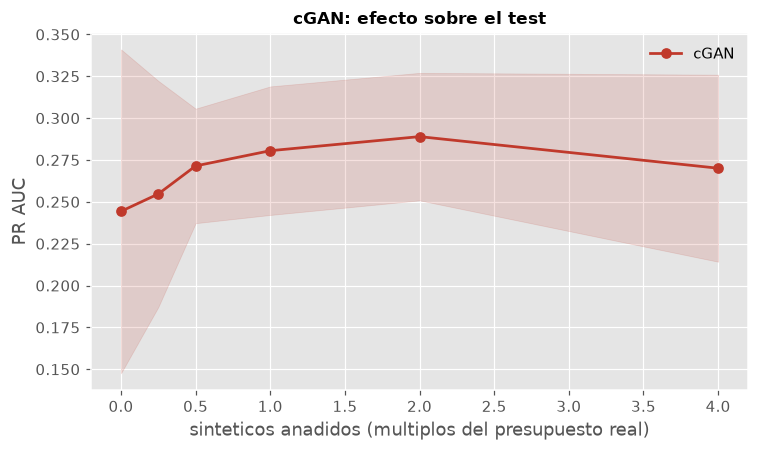

PR-AUC sin sintéticos: 0.2443
Mejor PR-AUC:          0.2890 con ratio 2
Variación:             +18.3 %


In [14]:
graficos.curva_ratios(
    resumen_cgan, titulo="cGAN: efecto sobre el test",
    nombre_fichero="04_curva_ratios")
plt.show()

base = resumen_cgan.loc[resumen_cgan["ratio"] == 0.0, "pr_auc_media"].iloc[0]
mejor = resumen_cgan.loc[resumen_cgan["pr_auc_media"].idxmax()]
print(f"PR-AUC sin sintéticos: {base:.4f}")
print(f"Mejor PR-AUC:          {mejor['pr_auc_media']:.4f} "
      f"con ratio {mejor['ratio']:g}")
print(f"Variación:             {100 * (mejor['pr_auc_media'] - base) / base:+.1f} %")

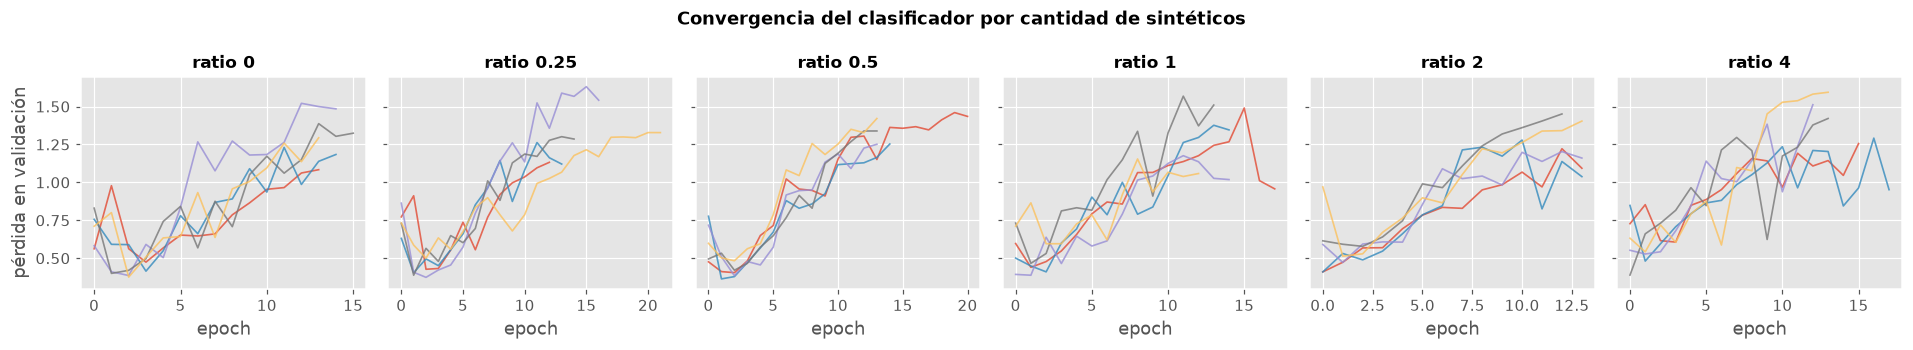

In [15]:
ratios_mostrados = sorted({r for r, _ in historias_cgan})
fig, axes = plt.subplots(1, len(ratios_mostrados),
                         figsize=(2.9 * len(ratios_mostrados), 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, ratio in zip(axes, ratios_mostrados):
    for (r, semilla), historia in historias_cgan.items():
        if r == ratio:
            ax.plot(historia["val_loss"], linewidth=1.1, alpha=0.8)
    ax.set_title(f"ratio {ratio:g}")
    ax.set_xlabel("epoch")

axes[0].set_ylabel("pérdida en validación")
fig.suptitle("Convergencia del clasificador por cantidad de sintéticos",
             fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "04_perdidas_clasificador")
plt.show()

## 9. Significación de las diferencias

Las medias por si solas no bastan. Con cinco semillas por configuración y un
conjunto de test que cubre un único régimen de mercado, una diferencia aparente
puede deberse por completo a la variabilidad del ajuste. Se contrasta por tanto
cada configuración frente a la referencia sin datos sintéticos.

In [16]:
from scipy import stats

referencia = resultados_cgan[resultados_cgan["ratio"] == 0.0]
filas_contraste = []

for ratio in sorted(resultados_cgan["ratio"].unique()):
    if ratio == 0.0:
        continue
    grupo = resultados_cgan[resultados_cgan["ratio"] == ratio]
    fila = {"ratio": ratio}
    for metrica, nombre in [("pr_auc", "PR-AUC test"),
                            ("pr_auc_val", "PR-AUC validación"),
                            ("f1", "F1 test")]:
        t, p = stats.ttest_ind(grupo[metrica], referencia[metrica], equal_var=False)
        fila[f"{nombre}: diferencia"] = grupo[metrica].mean() - referencia[metrica].mean()
        fila[f"{nombre}: p"] = p
    filas_contraste.append(fila)

contraste = pd.DataFrame(filas_contraste).set_index("ratio")
display(contraste.round(4))

print()
print("Desviación típica entre semillas del PR-AUC en test:")
for ratio in sorted(resultados_cgan["ratio"].unique()):
    sd = resultados_cgan[resultados_cgan["ratio"] == ratio]["pr_auc"].std()
    print(f"  ratio {ratio:<5g} -> {sd:.4f}")

,PR-AUC test: diferencia,PR-AUC test: p,PR-AUC validación: diferencia,PR-AUC validación: p,F1 test: diferencia,F1 test: p
ratio,,,,,,
0.25,0.0104,0.8493,0.0049,0.6685,0.0283,0.3500
0.50,0.0271,0.5802,-0.0059,0.7786,0.0371,0.2475
1.00,0.0362,0.4702,-0.0085,0.4297,0.0602,0.0710
2.00,0.0446,0.3795,0.0098,0.4926,0.0718,0.0401
4.00,0.0258,0.6235,-0.0113,0.3854,0.0385,0.1960



Desviación típica entre semillas del PR-AUC en test:
  ratio 0     -> 0.0967
  ratio 0.25  -> 0.0675
  ratio 0.5   -> 0.0342
  ratio 1     -> 0.0384
  ratio 2     -> 0.0381
  ratio 4     -> 0.0558


## Conclusiones del notebook

1. **El entrenamiento alcanzo un régimen equilibrado.** Tras una fase inicial
   inestable, en la que el generador llego a dominar durante unas dos mil
   iteraciones, la tasa de acierto del discriminador se estabiliza algo por
   debajo de la mitad y permanece ahi hasta el final. Ese es el comportamiento
   que se busca en un esquema adversario, y contrasta con el colapso que produce
   el procedimiento habitual de congelar el discriminador una sola vez.

2. **Las muestras son visualmente indistinguibles de las reales.** Las
   trayectorias generadas presentan la irregularidad y la alternancia de tramos
   propias de una serie de rentabilidades, sin las oscilaciones suavizadas ni la
   saturación en los extremos que delatarian un generador mal ajustado.

3. **La reproducción estadística es desigual.** La curtosis se conserva e incluso
   se acentua, de modo que el modelo capta las colas pesadas que caracterizan al
   problema. En cambio la correlación media entre activos queda por debajo de la
   real, y el diagrama de dispersión muestra un sesgo sistemático hacia valores
   menores. Puesto que el drawdown se mide sobre la cartera agregada, y es
   justamente la sincronia entre activos la que determina su magnitud, se trata
   de la limitación más relevante del generador en este problema. La volatilidad
   generada resulta además algo superior a la real de forma uniforme.

4. **Las muestras aportan configuraciones nuevas.** A diferencia del generador
   por ruido, cuyas muestras se situaban a una distancia mínima de alguna ventana
   real, las del cGAN se alejan lo suficiente como para no ser variantes locales
   de los datos de partida. El generador esta muestreando de una distribución
   aprendida y no reproduciendo el conjunto de entrenamiento.

5. **El efecto sobre el clasificador es positivo pero moderado.** El PR-AUC en
   test crece de forma sostenida hasta una proporción de dos veces el presupuesto
   real y decae después, patrón coherente con la idea de que una cantidad
   excesiva de dato sintético acaba desplazando a la señal real. La mejora en F1
   alcanza significación estadística en esa proporción; la del PR-AUC no la
   alcanza, porque la variabilidad del test es demasiado alta para detectar un
   efecto de esa magnitud con cinco semillas. En validación no se aprecia mejora.
   La lectura prudente es que existe un efecto favorable de tamaño pequeño, no
   una mejora rotunda.

6. **El efecto más claro y consistente es la reducción de la varianza.** La
   desviación típica del PR-AUC entre semillas se reduce a menos de la mitad al
   incorporar datos sintéticos. Con independencia de cuanto suba la media, el
   clasificador se vuelve considerablemente menos sensible a la inicialización, lo
   que en un problema con tan pocos episodios de estrés tiene valor por si mismo.

7. **Supera con claridad al generador por ruido.** Aquel degradaba el
   rendimiento de forma monótona conforme se anadian muestras; este lo mantiene o
   lo mejora en todo el rango. La diferencia entre ambos justifica el coste de
   entrenar un modelo generativo frente a limitarse a perturbar los datos
   existentes.